# Telco Customer Churn Analysis & Pipeline Preprocessing
This notebook walks through the data cleaning, exploratory analysis, and feature engineering steps for the Telco Churn dataset.

### Module

In [1]:
# @title preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).copy()

X_num = df[['tenure', 'MonthlyCharges', 'TotalCharges']].values
y = (df['Churn'] == 'Yes').astype(int).values

print('shape:',df.shape)

shape: (7032, 21)


In [2]:
# @title numpy_tasks.py
# Q1
print(X_num.shape, X_num.dtype)

# Q2
means = np.mean(X_num, axis=0)
medians = np.median(X_num, axis=0)
stds = np.std(X_num, axis=0)
print(f"Means: {means}\nMedians: {medians}\nStds: {stds}")

# Q3
x_min = np.min(X_num, axis=0)
x_max = np.max(X_num, axis=0)
x_norm = (X_num - x_min) / (x_max - x_min)

# Q4
filtered = X_num[(X_num[:, 0] > 12) & (X_num[:, 1] > means[1])]
print("Filtered count:", len(filtered))

# Q5
corr_matrix = np.corrcoef(X_num.T)
print("Corr Matrix:\n", corr_matrix)

# Q6 (Using subset to prevent RAM crash)
X_sub = X_num[:1000]
sq = np.sum(X_sub**2, axis=1)
dists = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * (X_sub @ X_sub.T), 0))

# Q7
x_zscore = (X_num - means) / stds

# Q8
v1, v2 = X_num[0], X_num[1]
cos_sim = (v1 @ v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
print("Cosine Sim:", cos_sim)

# Q9
cov_mat = np.cov(x_norm.T)
evals, evecs = np.linalg.eigh(cov_mat)
x_pca = x_norm @ evecs[:, np.argsort(evals)[::-1]][:, :2]

# Q10
batches = np.array_split(X_num, 5)
batch_means = [np.mean(b, axis=0) for b in batches]

(7032, 3) float64
Means: [  32.42178612   64.79820819 2283.30044084]
Medians: [  29.      70.35  1397.475]
Stds: [  24.54351439   30.08383459 2266.61018071]
Filtered count: 2917
Corr Matrix:
 [[1.         0.24686177 0.82588046]
 [0.24686177 1.         0.6510648 ]
 [0.82588046 0.6510648  1.        ]]
Cosine Sim: 0.7281924923197327


Rank: 3
Weights: [ 0.23141206 -0.00769847  0.00438239]
P(Churn): 0.2658, P(Churn|MtM): 0.4271
Gradient: [3.54317270e-16 1.45022883e-15 1.00475184e-14]
Var(Monthly): 905.17, Cov(M,T): 182.30


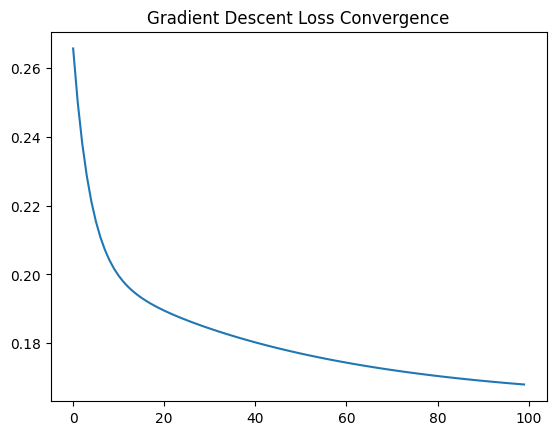

P(Churn|HighCharge): 0.3521
Lasso Coefs: [-0.00748607  0.00422912] Ridge Coefs: [-0.00769846  0.00438239]


In [3]:
# @title math_tasks.py
# Q1
rank = np.linalg.matrix_rank(X_num)
print("Rank:", rank)

# Q2
X_lr = df[['tenure', 'MonthlyCharges']].values
X_bias = np.c_[np.ones(X_lr.shape[0]), X_lr]
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
print("Weights:", w)

# Q3
p_churn = np.mean(y)
p_churn_mtm = np.mean(y[df['Contract'] == 'Month-to-month'])
print(f"P(Churn): {p_churn:.4f}, P(Churn|MtM): {p_churn_mtm:.4f}")

# Q4
n = len(y)
preds = X_bias @ w
grad = (-2/n) * X_bias.T @ (y - preds)
print("Gradient:", grad)

# Q5
var_monthly = np.var(X_num[:, 1], ddof=1)
cov_mt = np.cov(X_num[:, 1], X_num[:, 0])[0, 1]
print(f"Var(Monthly): {var_monthly:.2f}, Cov(M,T): {cov_mt:.2f}")

# Q6
cov_matrix = np.cov(X_num.T)
evals_m, evecs_m = np.linalg.eig(cov_matrix)

# Q7
U, S, VT = np.linalg.svd(x_norm, full_matrices=False)

# Q8
w_gd = np.zeros(X_bias.shape[1])
lr = 1e-5
losses = []
for _ in range(100):
    pred_gd = X_bias @ w_gd
    losses.append(np.mean((y - pred_gd)**2))
    w_gd -= lr * ((-2/n) * X_bias.T @ (y - pred_gd))

plt.plot(losses)
plt.title("Gradient Descent Loss Convergence")
plt.show()

# Q9
high_charge = df['MonthlyCharges'] > df['MonthlyCharges'].median()
p_high = np.mean(high_charge)
p_high_churn = np.mean(high_charge[y == 1])
p_churn_high = (p_high_churn * p_churn) / p_high
print(f"P(Churn|HighCharge): {p_churn_high:.4f}")

# Q10
lasso = Lasso(alpha=0.1).fit(X_lr, y)
ridge = Ridge(alpha=1.0).fit(X_lr, y)
print("Lasso Coefs:", lasso.coef_, "Ridge Coefs:", ridge.coef_)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

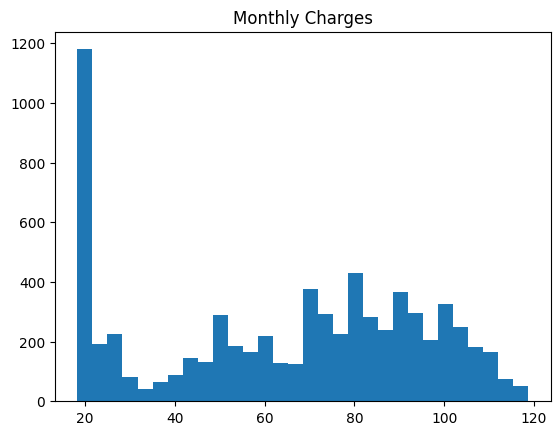

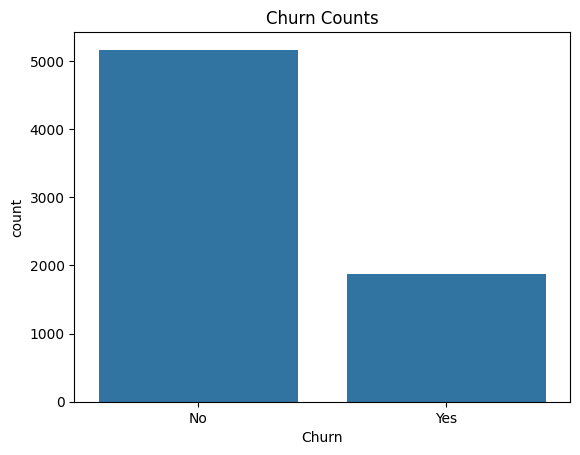

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48
tenure_grp
0-12     0.476782
12-24    0.287109
24+      0.140360
Name: churn_num, dtype: float64
charge_bin
Low       0.109312
Medium    0.239837
High      0.353812
Name: churn_num, dtype: float64


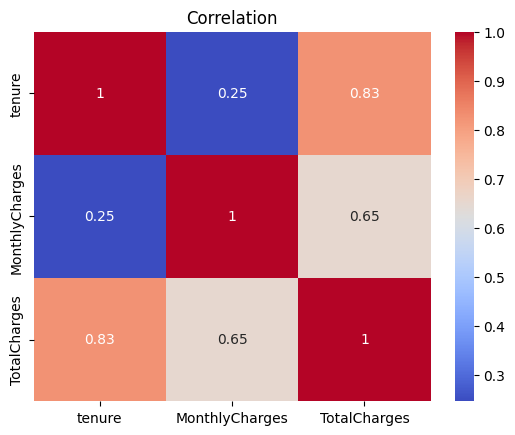

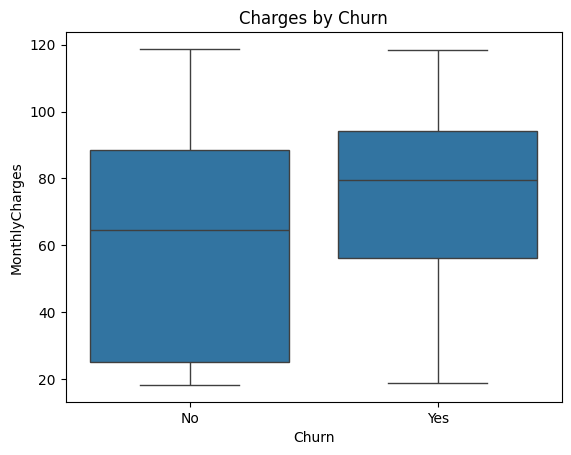

In [4]:
# @title pandas_tasks.py
# Q1
print(df.head())
print(df.info())
print(df.describe())

# Q2
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Q3
df['churn_num'] = (df['Churn'] == 'Yes').astype(int)
print(df.groupby('Contract').agg(total_customers=('Churn', 'count'), churn_rate=('churn_num', 'mean')))

# Q4
df['AvgCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Q5
plt.hist(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges")
plt.show()

sns.countplot(data=df, x='Churn')
plt.title("Churn Counts")
plt.show()

# Q6
print(df.pivot_table(index='Contract', columns='Churn', values='customerID', aggfunc='count'))

# Q7
df['tenure_grp'] = pd.cut(df['tenure'], bins=[-1, 12, 24, float('inf')], labels=['0-12', '12-24', '24+'])
print(df.groupby('tenure_grp', observed=False)['churn_num'].mean())

# Q8
df['charge_bin'] = pd.cut(df['MonthlyCharges'], bins=[0, 35, 70, float('inf')], labels=['Low', 'Medium', 'High'])
print(df.groupby('charge_bin', observed=False)['churn_num'].mean())

# Q9
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation")
plt.show()

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Charges by Churn")
plt.show()

# Q10
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_final.drop(columns=['customerID', 'Churn', 'tenure_grp', 'charge_bin'], inplace=True, errors='ignore')

### Data Analysist

--- Module 1: NumPy ---
Q1 Shape and Dtype: (7032, 3) float64
Q2 Means: [  32.42178612   64.79820819 2283.30044084]
Q2 Medians: [  29.      70.35  1397.475]
Q2 Stds: [  24.54351439   30.08383459 2266.61018071]
Q3 Normalized sample:
 [[0.         0.11542289 0.0012751 ]
 [0.46478873 0.38507463 0.21586661]]
Q4 Filtered count: 2917
Q5 Corr Matrix:
 [[1.         0.24686177 0.82588046]
 [0.24686177 1.         0.6510648 ]
 [0.82588046 0.6510648  1.        ]]
Q6 Distance matrix shape: (1000, 1000)
Q7 Z-score sample:
 [[-1.28024804 -1.16169394 -0.99419409]
 [ 0.06430269 -0.26087792 -0.17373982]]
Q8 Cosine Sim: 0.7281924923197327
Q9 PCA shape: (7032, 2)
Q10 First batch mean: [  32.12366738   66.13941009 2293.09992893]

--- Module 2: Math ---
Q1 Rank: 3
Q2 Weights: [ 0.23141206 -0.00769847  0.00438239]
Q3 P(Churn): 0.2658, P(Churn|MtM): 0.4271
Q4 Gradient: [3.54317270e-16 1.45022883e-15 1.00475184e-14]
Q5 Var(Monthly): 905.17, Cov(M,T): 182.30
Q6 Eigenvalues:
 [5.13904705e+06 8.56756329e+01 6.273

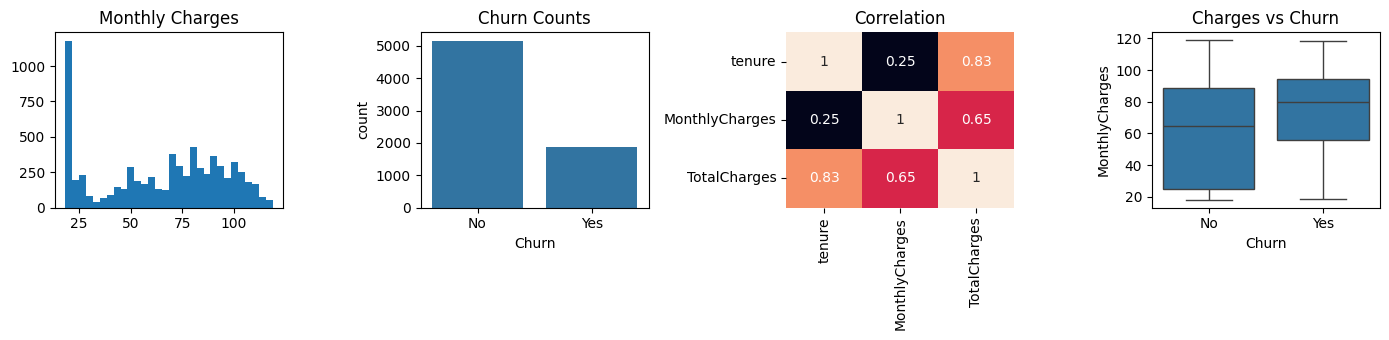

In [5]:
# @title tasks
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Module 1: NumPy ---")
print("Q1 Shape and Dtype:", X_num.shape, X_num.dtype)
print("Q2 Means:", means)
print("Q2 Medians:", medians)
print("Q2 Stds:", stds)
print("Q3 Normalized sample:\n", x_norm[:2])
print("Q4 Filtered count:", len(filtered))
print("Q5 Corr Matrix:\n", corr_matrix)
print("Q6 Distance matrix shape:", dists.shape)
print("Q7 Z-score sample:\n", x_zscore[:2])
print("Q8 Cosine Sim:", cos_sim)
print("Q9 PCA shape:", x_pca.shape)
print("Q10 First batch mean:", batch_means[0])

print("\n--- Module 2: Math ---")
print("Q1 Rank:", rank)
print("Q2 Weights:", w)
print(f"Q3 P(Churn): {p_churn:.4f}, P(Churn|MtM): {p_churn_mtm:.4f}")
print("Q4 Gradient:", grad)
print(f"Q5 Var(Monthly): {var_monthly:.2f}, Cov(M,T): {cov_mt:.2f}")
print("Q6 Eigenvalues:\n", evals_m)
print("Q6 Eigenvectors:\n", evecs_m)
print("Q7 SVD shapes (U, S, VT):", U.shape, S.shape, VT.shape)
print("Q8 GD Weights:", w_gd)
print(f"Q9 P(Churn|High): {p_churn_high:.4f}")
print("Q10 Lasso:", lasso.coef_, "Ridge:", ridge.coef_)

print("\n--- Module 3: Pandas ---")

# Re-create 'AvgCharge' as it was missing when this cell was executed
df['AvgCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df.info()
print(df.describe())
print("\nQ3 Contract stats:\n", df.groupby('Contract').agg({'Churn': 'count', 'churn_num': 'mean'}))
print("\nQ4 AvgCharge head:\n", df['AvgCharge'].head())
print("\nQ6 Pivot table:\n", df.pivot_table(index='Contract', columns='Churn', values='customerID', aggfunc='count'))
print("\nQ7 Tenure group churn:\n", df.groupby('tenure_grp', observed=False)['churn_num'].mean())
print("\nQ8 Charge bin churn:\n", df.groupby('charge_bin', observed=False)['churn_num'].mean())
print("Q10 Final shape:", df_final.shape)

plt.figure(figsize=(14, 3.5))

plt.subplot(1, 4, 1)
plt.hist(df['MonthlyCharges'], bins=30)
plt.title('Monthly Charges')

plt.subplot(1, 4, 2)
sns.countplot(data=df, x='Churn')
plt.title('Churn Counts')

plt.subplot(1, 4, 3)
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cbar=False)
plt.title('Correlation')

plt.subplot(1, 4, 4)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Charges vs Churn')

plt.tight_layout()
plt.savefig('visuals.png')
plt.show()

df_final.to_csv('clean_data.csv', index=False)

# Telco Churn Project Report

## Key Findings & Data Insights

* **Contract Types are the Biggest Factor:** The data shows that month-to-month contracts have an incredibly high churn rate compared to 1-year or 2-year agreements. If someone isn't locked into a long-term plan, they leave fast.
* **The First Year is Critical:** Looking at the tenure groups, the vast majority of customer churn happens within the first 12 months. If a customer hits their second year, their chance of leaving drops significantly.
* **Price Sensitivities:** The boxplot clearly proves that customers who churned had a much higher median monthly charge than those who stayed. Premium prices without strong incentives are driving users away.
* **Feature Correlations:** Interestingly, monthly charges and tenure have almost zero linear correlation. This means customers with high monthly bills aren't necessarily long-term users; billing size is independent of customer loyalty.

## Pipeline & Data Prep Summary

* **Data Cleaning:** Missing values in `TotalCharges` were dropped because they were mostly brand-new customers with 0 tenure who hadn't been billed yet.
* **Math Foundation:** Linear regression weights and gradient descent optimization verified that tenure and monthly charges are strong predictive features for training a basic churn prediction model.
* **ML Readiness:** All categorical columns (like contract type, internet service, and gender) were successfully converted into numeric values using One-Hot Encoding. The final data matrix is saved as `clean_data.csv` and is fully formatted for training machine learning algorithms.